In [ ]:
pip install seaborn matplotlib


Please enter the following details:
Enter Pregnancies: 5
Enter Glucose: 116
Enter BloodPressure: 74
Enter SkinThickness: 0
Enter Insulin: 0
Enter BMI: 25.6
Enter DiabetesPedigreeFunction: 0.201
Enter Age: 30


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Based on the input, the person is predicted not to be diabetic.
Accuracy: 0.7597402597402597
Confusion Matrix:
[[81 18]
 [19 36]]


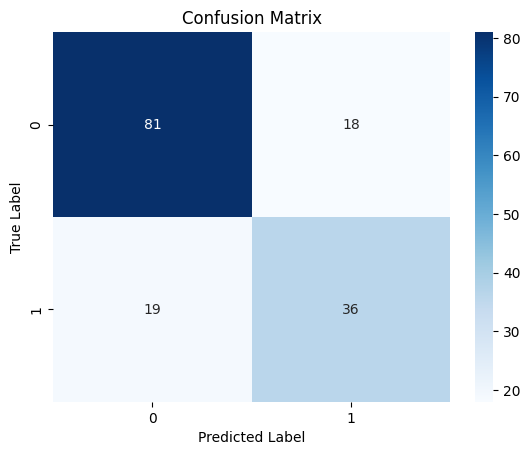

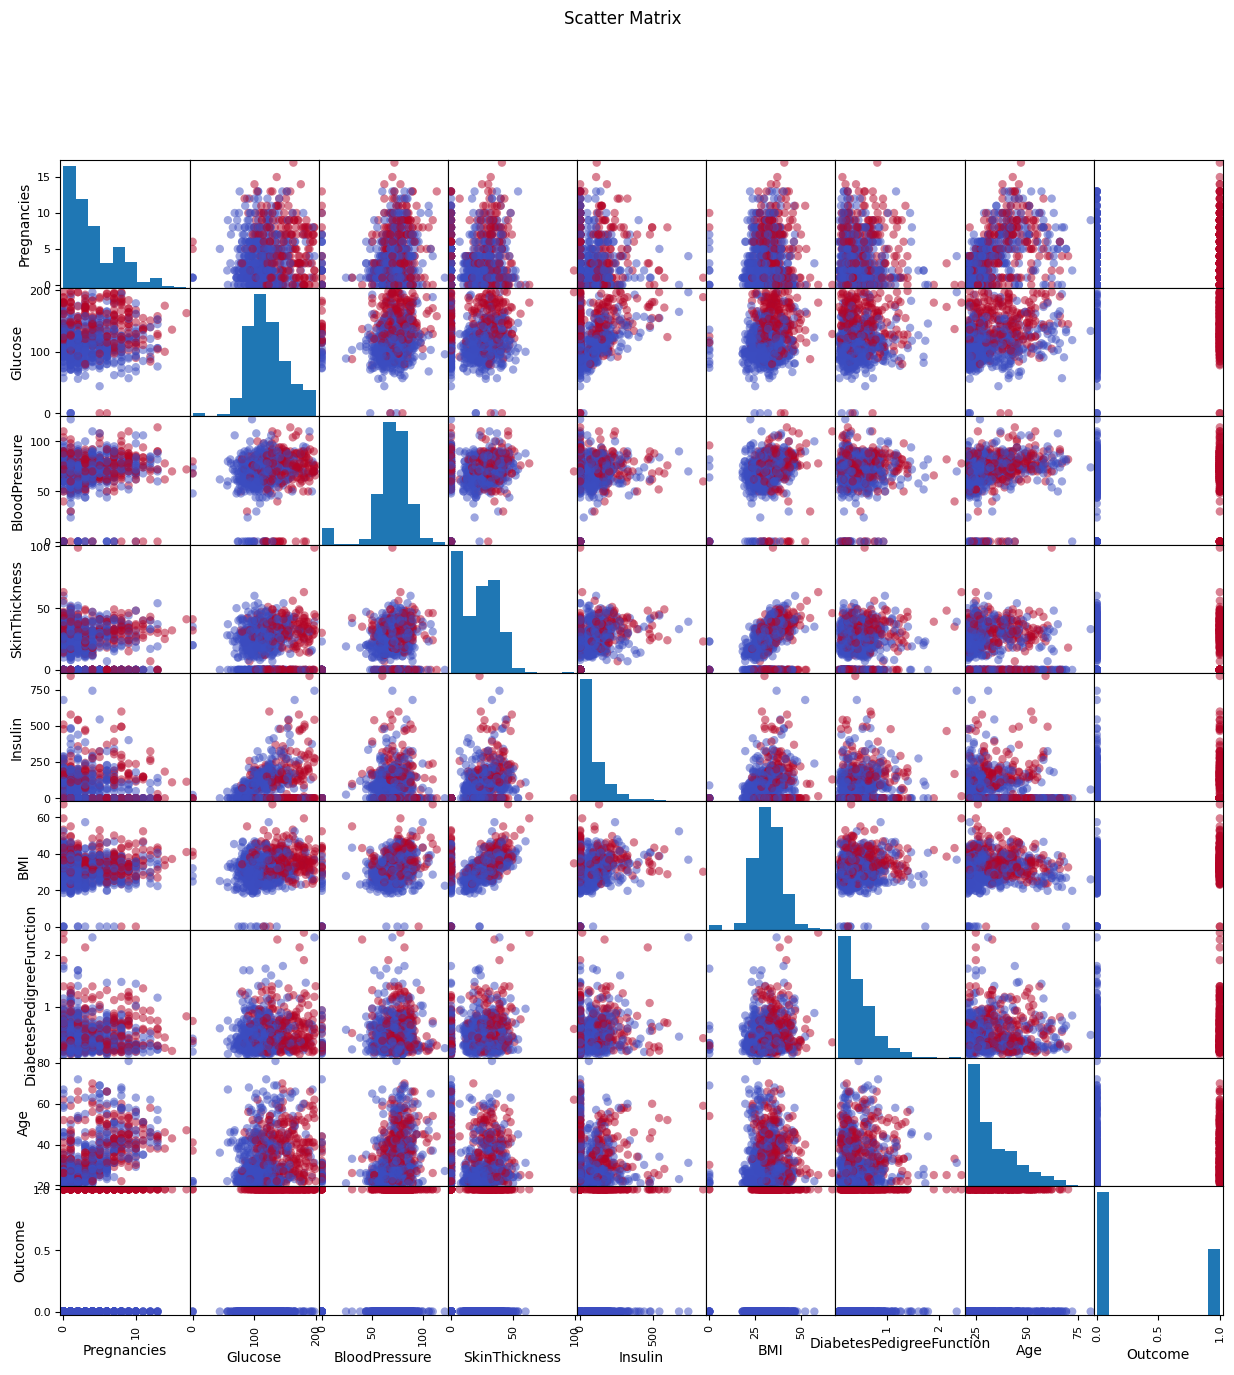

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from pandas.plotting import scatter_matrix

# Load the dataset
data = pd.read_csv('diabetes.csv')

# Split the data into features (X) and target variable (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM classifier
clf = SVC(kernel='linear')
clf.fit(X_train_scaled, y_train)

# Function to get user input
def get_user_input():
    feature_names = X.columns
    user_input = [float(input(f"Enter {feature}: ")) for feature in feature_names]
    return user_input

# Get user input for prediction
print("Please enter the following details:")
user_input = get_user_input()
input_data_scaled = scaler.transform([user_input])
prediction = clf.predict(input_data_scaled)

# Display prediction result
if prediction == 1:
    print("Based on the input, the person is predicted to be diabetic.")
else:
    print("Based on the input, the person is predicted not to be diabetic.")

# Evaluate the model on the test set
y_pred = clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Scatter Matrix
scatter_matrix(data, c=y, figsize=(15, 15), marker='o', cmap='coolwarm')
plt.suptitle('Scatter Matrix')
plt.show()